In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression ,SGDRegressor

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [3]:
X = 6 * np.random.rand(200,1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 +np.random.randn(200,1)

# y = 0.8x^2 + 0.9x + 2

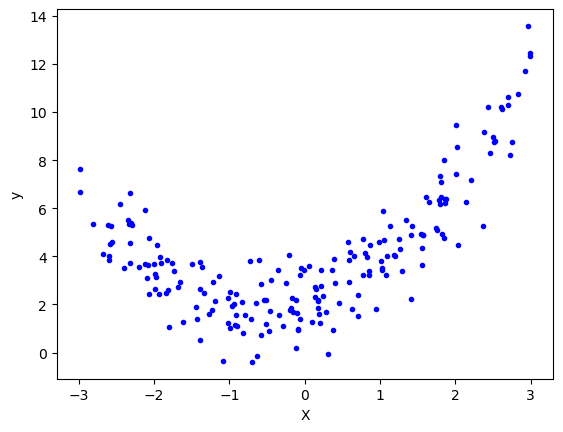

In [4]:
plt.plot(X,y,'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.show()


In [5]:
#train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [6]:
# Applying linear regression
lr = LinearRegression()

In [7]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
y_pred = lr.predict(X_test)
r2_score(y_test,y_pred)

0.29807546122289097

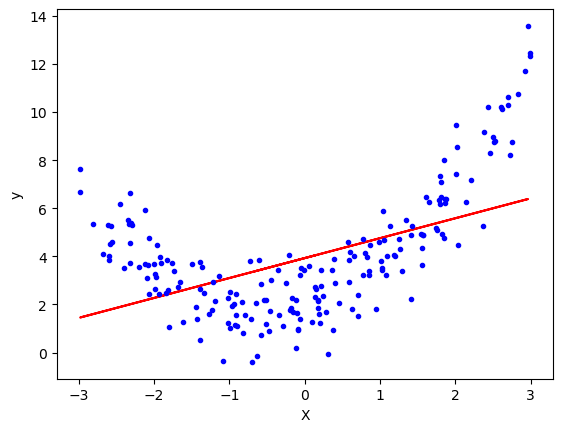

In [10]:
plt.plot(X_train,lr.predict(X_train),color = 'red')
plt.plot(X,y,"b.")
plt.xlabel('X')
plt.ylabel('y')
plt.show()


In [11]:
poly = PolynomialFeatures(degree=2)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

In [13]:
print(X_train[0])
print(X_train_trans[0])

[-0.65231714]
[ 1.         -0.65231714  0.42551765]


In [14]:
lr = LinearRegression()

In [15]:
lr.fit(X_train_trans,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
y_pred = lr.predict(X_test_trans)

In [17]:
r2_score(y_test,y_pred)

0.841872305975338

In [18]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.79976275 0.82330203]]
[1.98136481]


In [20]:
X_new = np.linspace(-3,3,200).reshape(200,1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

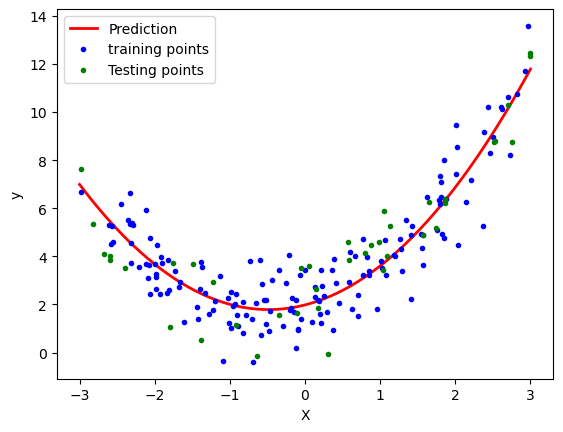

In [26]:
plt.plot(X_new,y_new, "r-",linewidth = 2 ,label = 'Prediction')
plt.plot(X_train,y_train,'b.', label = "training points")
plt.plot(X_test,y_test,"g.",label="Testing points")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()